In [1]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import catboost as cb
from category_encoders import TargetEncoder
warnings.filterwarnings('ignore')

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e3/train.csv
/kaggle/input/competitions/playground-series-s6e3/test.csv


In [2]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')
sample_submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv')
print('Train shape:', train.shape)
print('Test shape:', test.shape)
train.head()

Train shape: (594194, 21)
Test shape: (254655, 20)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [3]:
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [5]:
train.shape

(594194, 21)

In [6]:
TARGET = 'Churn'
ID_COL = 'id'
print(train.info())
print('\nMissing values:')
print(train.isnull().sum().sort_values(ascending=False).head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [7]:
# --- Map Churn to 0/1 (only if it's still a string) ---
if train[TARGET].dtype == object:
    train[TARGET] = train[TARGET].map({'Yes': 1, 'No': 0})

print('Churn distribution:')
print(train[TARGET].value_counts())
print(f'Churn rate: {train[TARGET].mean():.3f}')

Churn distribution:
Churn
0    460377
1    133817
Name: count, dtype: int64
Churn rate: 0.225


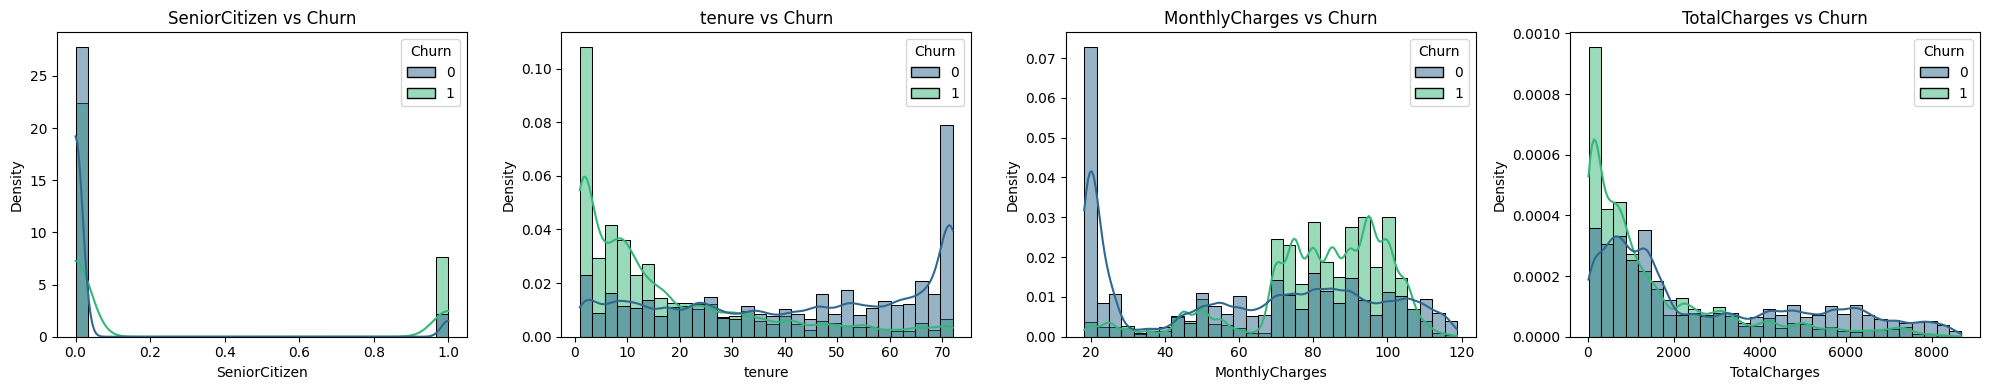

In [8]:
# Numeric feature distributions vs Churn
NUMERICAL_COLS = train.select_dtypes(include=['int64','float64']).columns.tolist()
NUMERICAL_COLS = [c for c in NUMERICAL_COLS if c not in [TARGET, ID_COL]]

fig, axes = plt.subplots(1, len(NUMERICAL_COLS), figsize=(5*len(NUMERICAL_COLS), 4))
for i, col in enumerate(NUMERICAL_COLS):
    ax = axes[i] if len(NUMERICAL_COLS) > 1 else axes
    sns.histplot(data=train, x=col, hue=TARGET, bins=30,
                 palette='viridis', kde=True, stat='density', common_norm=False, ax=ax)
    ax.set_title(f'{col} vs {TARGET}')
plt.tight_layout()
plt.show()

In [9]:
# Target encoding features — fit on TRAIN, apply to TEST
TARGET_ENCODE_COLS = [
    'Contract', 'InternetService', 'PaymentMethod'
]

# Interaction columns also target-encoded
INTERACTION_ENCODE_COLS = [
    'Contract_x_InternetService',
    'Payment_x_Paperless',
    'OnlineSecurity_x_TechSupport'
]

ALL_TE_COLS = TARGET_ENCODE_COLS + INTERACTION_ENCODE_COLS


def add_base_features(df):
    """Pure numeric/string features — no target needed."""
    df = df.copy()
    epsilon = 1e-6

    # Fix TotalCharges if needed
    if df['TotalCharges'].dtype == object:
        df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'] = df['TotalCharges'].fillna(0)

    # Ratio features
    df['Monthly_to_Total_Ratio']    = df['MonthlyCharges'] / (df['TotalCharges'] + epsilon)
    df['Avg_Monthly_over_Tenure']   = df['TotalCharges']   / (df['tenure'] + epsilon)
    df['Tenure_per_Monthly_Charge'] = df['tenure']         / (df['MonthlyCharges'] + epsilon)

    # Numeric interactions
    df['MonthlyCharges_x_SeniorCitizen'] = df['MonthlyCharges'] * df['SeniorCitizen']
    df['MonthlyCharges_x_TotalCharges']  = df['MonthlyCharges'] * df['TotalCharges']
    df['MonthlyCharges_x_tenure']        = df['MonthlyCharges'] * df['tenure']
    df['SeniorCitizen_x_TotalCharges']   = df['SeniorCitizen']  * df['TotalCharges']
    df['SeniorCitizen_x_tenure']         = df['SeniorCitizen']  * df['tenure']
    df['TotalCharges_x_tenure']          = df['TotalCharges']   * df['tenure']

    # Categorical interaction strings (used for TE)
    df['Contract_x_InternetService']     = df['Contract'].astype(str) + '_' + df['InternetService'].astype(str)
    df['Payment_x_Paperless']            = df['PaymentMethod'].astype(str) + '_' + df['PaperlessBilling'].astype(str)
    df['OnlineSecurity_x_TechSupport']   = df['OnlineSecurity'].astype(str) + '_' + df['TechSupport'].astype(str)

    # Service counts
    service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
    df['Num_Services_Yes']   = df[service_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)
    df['Has_Any_Streaming']  = ((df['StreamingTV'] == 'Yes') | (df['StreamingMovies'] == 'Yes')).astype(int)
    df['Has_Any_Protection'] = ((df['DeviceProtection'] == 'Yes') | (df['TechSupport'] == 'Yes')).astype(int)

    # Tenure bucket
    df['Tenure_Bucket'] = pd.cut(df['tenure'], bins=[0,12,24,48,100], labels=['0-12','13-24','25-48','49+'])

    # Contract binaries
    df['Is_Month_to_Month'] = (df['Contract'] == 'Month-to-month').astype(int)
    df['Is_One_Year']       = (df['Contract'] == 'One year').astype(int)
    df['Is_Two_Year']       = (df['Contract'] == 'Two year').astype(int)

    # Demographic interactions
    df['SeniorCitizen_x_Partner'] = df['SeniorCitizen'].astype(str) + '_' + df['Partner'].astype(str)
    df['Partner_x_Dependents']    = df['Partner'].astype(str) + '_' + df['Dependents'].astype(str)

    return df


# Apply base features
train_feat = add_base_features(train)
test_feat  = add_base_features(test)

print('Features added. Train shape:', train_feat.shape)

Features added. Train shape: (594194, 42)


In [10]:
# --- Target Encoding: fit on train, transform both ---
te_encoder = TargetEncoder(cols=ALL_TE_COLS, smoothing=10)
te_encoder.fit(train_feat[ALL_TE_COLS], train_feat[TARGET])

te_train = te_encoder.transform(train_feat[ALL_TE_COLS])
te_test  = te_encoder.transform(test_feat[ALL_TE_COLS])

# Rename columns
te_train.columns = ['TE_' + c for c in te_train.columns]
te_test.columns  = ['TE_' + c for c in te_test.columns]

train_feat = pd.concat([train_feat, te_train], axis=1)
test_feat  = pd.concat([test_feat,  te_test],  axis=1)

print('Target encoding done.')
print('Train shape:', train_feat.shape)
train_feat.head()

Target encoding done.
Train shape: (594194, 48)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Is_One_Year,Is_Two_Year,SeniorCitizen_x_Partner,Partner_x_Dependents,TE_Contract,TE_InternetService,TE_PaymentMethod,TE_Contract_x_InternetService,TE_Payment_x_Paperless,TE_OnlineSecurity_x_TechSupport
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,1,0,0_Yes,Yes_Yes,0.057628,0.103064,0.079697,0.022020,0.160933,0.031841
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,0,1,0_Yes,Yes_Yes,0.009982,0.103064,0.069332,0.004035,0.027836,0.031841
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,0,0,0_Yes,Yes_No,0.420543,0.415366,0.489052,0.550093,0.520402,0.469848
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,0,0,0_No,No_No,0.420543,0.415366,0.489052,0.550093,0.520402,0.469848
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,0,0,0_No,No_No,0.420543,0.415366,0.489052,0.550093,0.520402,0.469848


In [11]:
# --- Prepare X / y ---
DROP_COLS = [TARGET, ID_COL]

X = train_feat.drop(columns=DROP_COLS, errors='ignore')
y = train_feat[TARGET]
X_test_raw = test_feat.drop(columns=DROP_COLS, errors='ignore')

# One-hot encode remaining categoricals
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
X_enc      = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X_test_enc = pd.get_dummies(X_test_raw, columns=cat_cols, drop_first=True)

# Align (train is reference)
X_enc, X_test_enc = X_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

print('X_enc shape:', X_enc.shape)
print('X_test_enc shape:', X_test_enc.shape)

X_enc shape: (594194, 79)
X_test_enc shape: (254655, 79)


In [12]:
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print(f'Class imbalance ratio (neg/pos): {scale_pos_weight:.2f}')

NFOLDS = 5
skf = StratifiedKFold(n_splits=NFOLDS, shuffle=True, random_state=42)

oof_preds  = pd.DataFrame(index=X_enc.index)
test_preds = pd.DataFrame(index=X_test_enc.index)
fold_scores = defaultdict(list)

# --- Model definitions (tuned for speed + performance) ---
def make_models(spw):
    return {
        'XGBoost': XGBClassifier(
            objective='binary:logistic', eval_metric='auc',
            n_estimators=3000, learning_rate=0.02,
            max_depth=6, min_child_weight=3, gamma=0.1,
            subsample=0.8, colsample_bytree=0.7,
            reg_alpha=0.05, reg_lambda=1.0,
            scale_pos_weight=spw,
            tree_method='hist', n_jobs=-1, random_state=42,
            early_stopping_rounds=100
        ),
        'LightGBM': LGBMClassifier(
            n_estimators=3000, learning_rate=0.02,
            num_leaves=63, max_depth=-1,
            subsample=0.8, colsample_bytree=0.7,
            reg_alpha=0.05, reg_lambda=1.0,
            scale_pos_weight=spw,
            n_jobs=-1, random_state=42, verbose=-1
        ),
        'CatBoost': cb.CatBoostClassifier(
            iterations=3000, learning_rate=0.02, depth=7,
            l2_leaf_reg=5, border_count=254,
            od_type='Iter', od_wait=150,
            loss_function='Logloss', eval_metric='AUC',
            auto_class_weights='Balanced',
            verbose=0, random_state=42, thread_count=-1
        ),
        'Logistic': LogisticRegression(
            solver='saga', penalty='elasticnet', C=0.3,
            l1_ratio=0.5, max_iter=2000, n_jobs=-1, random_state=42
        )
    }

print('Model configs ready.')

Class imbalance ratio (neg/pos): 3.44
Model configs ready.


In [13]:
scaler = StandardScaler()

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_enc, y)):
    print(f'\n========== Fold {fold+1}/{NFOLDS} ==========')

    X_tr, X_val = X_enc.iloc[tr_idx], X_enc.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx],     y.iloc[val_idx]

    # Scale for Logistic
    X_tr_sc  = scaler.fit_transform(X_tr)
    X_val_sc = scaler.transform(X_val)
    X_te_sc  = scaler.transform(X_test_enc)

    models = make_models(scale_pos_weight)

    for name, model in models.items():

        if name == 'XGBoost':
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
            val_pred  = model.predict_proba(X_val)[:, 1]
            test_pred = model.predict_proba(X_test_enc)[:, 1]

        elif name == 'LightGBM':
            model.fit(X_tr, y_tr,
                      eval_set=[(X_val, y_val)],
                      callbacks=[LGBMClassifier().fit.__func__  # placeholder to trigger early stop
                                ] if False else None)
            # LightGBM with early stopping via callbacks
            import lightgbm as lgb
            model2 = lgb.LGBMClassifier(
                n_estimators=3000, learning_rate=0.02, num_leaves=63,
                subsample=0.8, colsample_bytree=0.7,
                reg_alpha=0.05, reg_lambda=1.0,
                scale_pos_weight=scale_pos_weight,
                n_jobs=-1, random_state=42, verbose=-1
            )
            model2.fit(X_tr, y_tr,
                       eval_set=[(X_val, y_val)],
                       callbacks=[lgb.early_stopping(100, verbose=False),
                                  lgb.log_evaluation(-1)])
            val_pred  = model2.predict_proba(X_val)[:, 1]
            test_pred = model2.predict_proba(X_test_enc)[:, 1]
            model = model2  # use the fitted one

        elif name == 'CatBoost':
            model.fit(X_tr, y_tr,
                      eval_set=[(X_val, y_val)],
                      early_stopping_rounds=150, verbose=0)
            val_pred  = model.predict_proba(X_val)[:, 1]
            test_pred = model.predict_proba(X_test_enc)[:, 1]

        else:  # Logistic
            model.fit(X_tr_sc, y_tr)
            val_pred  = model.predict_proba(X_val_sc)[:, 1]
            test_pred = model.predict_proba(X_te_sc)[:, 1]

        oof_preds.loc[val_idx, name] = val_pred
        test_preds[f'{name}_fold{fold}'] = test_pred

        auc = roc_auc_score(y_val, val_pred)
        fold_scores[name].append(auc)
        print(f'  {name:12s}  AUC={auc:.5f}')

print('\nTraining complete!')


========== Fold 1/5 ==========
  XGBoost       AUC=0.91585
  LightGBM      AUC=0.91216
  CatBoost      AUC=0.91567
  Logistic      AUC=0.91135

========== Fold 2/5 ==========
  XGBoost       AUC=0.91680
  LightGBM      AUC=0.91313
  CatBoost      AUC=0.91686
  Logistic      AUC=0.91275

========== Fold 3/5 ==========
  XGBoost       AUC=0.91637
  LightGBM      AUC=0.91252
  CatBoost      AUC=0.91632
  Logistic      AUC=0.91186

========== Fold 4/5 ==========
  XGBoost       AUC=0.91732
  LightGBM      AUC=0.91391
  CatBoost      AUC=0.91718
  Logistic      AUC=0.91296

========== Fold 5/5 ==========
  XGBoost       AUC=0.91463
  LightGBM      AUC=0.91103
  CatBoost      AUC=0.91464
  Logistic      AUC=0.91006

Training complete!


In [14]:
print('\n===== OOF AUC Summary =====')
for name, scores in fold_scores.items():
    print(f'{name:12s}  mean={np.mean(scores):.5f}  std={np.std(scores):.5f}')


===== OOF AUC Summary =====
XGBoost       mean=0.91619  std=0.00092
LightGBM      mean=0.91255  std=0.00096
CatBoost      mean=0.91613  std=0.00091
Logistic      mean=0.91180  std=0.00105


In [15]:
# Simple average ensemble over models
model_names = list(fold_scores.keys())

# OOF ensemble
oof_ensemble = oof_preds[model_names].mean(axis=1)
oof_auc = roc_auc_score(y, oof_ensemble)
print(f'Ensemble OOF AUC: {oof_auc:.5f}')

# Test ensemble — average per model across folds, then average models
model_test_preds = {}
for name in model_names:
    fold_cols = [c for c in test_preds.columns if c.startswith(name)]
    model_test_preds[name] = test_preds[fold_cols].mean(axis=1)

test_ensemble = pd.DataFrame(model_test_preds).mean(axis=1)

print('Test prediction stats:')
print(test_ensemble.describe())

Ensemble OOF AUC: 0.91541
Test prediction stats:
count    254655.000000
mean          0.305628
std           0.306515
min           0.013809
25%           0.028348
50%           0.162687
75%           0.592118
max           0.948897
dtype: float64


In [16]:
# --- Create submission ---
submission = pd.DataFrame({
    'id':    test[ID_COL].values,
    'Churn': test_ensemble.values
})

submission.to_csv('submission.csv', index=False)
print('submission.csv saved!')
print(submission.head(10))
print('Shape:', submission.shape)

submission.csv saved!
       id     Churn
0  594194  0.182593
1  594195  0.014694
2  594196  0.241099
3  594197  0.018817
4  594198  0.663302
5  594199  0.346173
6  594200  0.885076
7  594201  0.017495
8  594202  0.111805
9  594203  0.534532
Shape: (254655, 2)


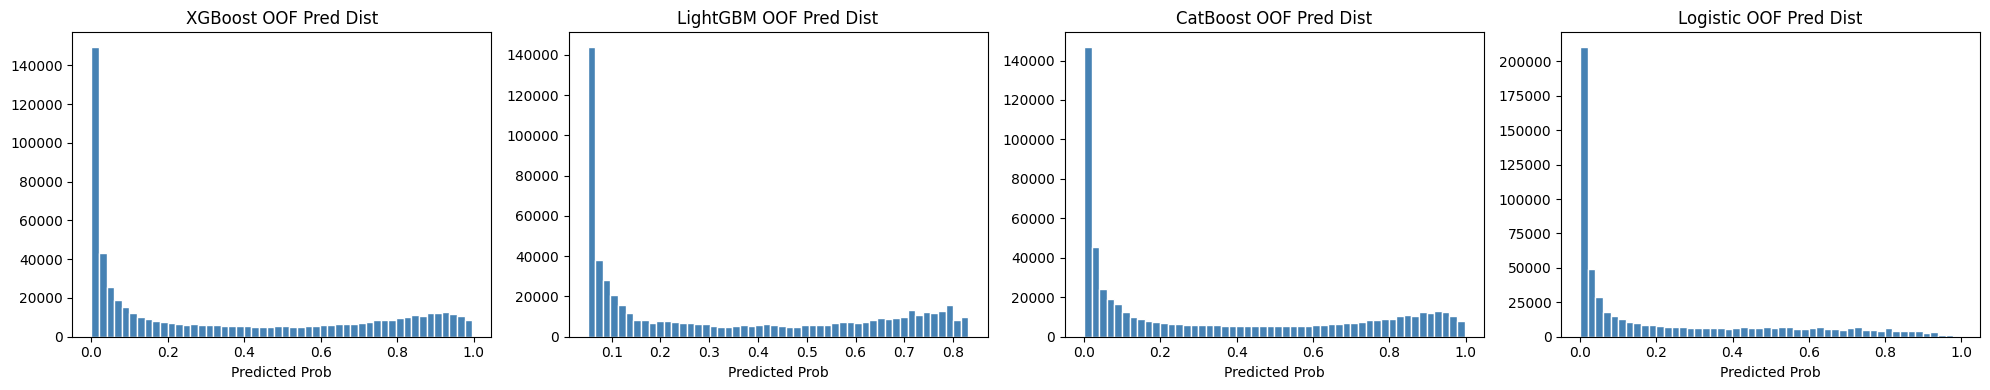

In [17]:
# --- Optional: plot OOF prediction distributions ---
fig, axes = plt.subplots(1, len(model_names), figsize=(5*len(model_names), 4))
for i, name in enumerate(model_names):
    ax = axes[i] if len(model_names) > 1 else axes
    ax.hist(oof_preds[name].dropna(), bins=50, color='steelblue', edgecolor='white')
    ax.set_title(f'{name} OOF Pred Dist')
    ax.set_xlabel('Predicted Prob')
plt.tight_layout()
plt.show()